# Session 10 — The Training Loop: making a small model tell the truth about itself

Five lines run every training job in the world:

```python
logits, loss = model(x, targets=y)   # forward
loss.backward()                      # fill in every gradient
optimizer.step()                     # move every weight
optimizer.zero_grad()                # wipe before the next batch
```

This notebook takes those lines apart and **checks them by hand**, because every
serious training bug is silent and the loss curve is not the one that will tell
you.

The assignment, point by point:

1. **Print every tensor shape** in the step, and say what each dimension means.
2. **Verify one gradient by hand** — nudge a weight, measure the loss change, compare to `backward()`.
3. **Break gradient accumulation on purpose** — average-of-averages vs. token-weighted, micro-batches of different lengths, both curves on one plot.
4. **Log the grad norm at every step**, then find a step where it moved before the loss did.
5. **Compute your own MFU**, report it honestly, and say what is costing you the distance to 40%.
6. **Take the number 0.1** and write it out in fp32, bf16 and fp8 E4M3, bit by bit. Say which one you would train in.

### How this notebook is organised

- `src/trainloop/model.py` — a compact nanoGPT-style decoder. Ordinary on purpose.
- `src/trainloop/data.py` — char-level Tiny Shakespeare + the batch samplers.
- `src/trainloop/utils.py` — seeding, device pick, the smoke switch.

Those three files are *plumbing*. **Every experiment below is done in the cells
themselves**, split into small steps.

> **Two scales.** Defaults are a small-GPU proxy. Set `S10_SMOKE=1`

## 0. Setup


In [60]:
import copy
import json
import math
import os
import struct
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

sys.path.insert(0, "src")
from trainloop import utils, data
from trainloop import model as model_mod


In [61]:
SMOKE = utils.is_smoke()
utils.seed_everything(1337)
DEVICE = utils.pick_device()
print(f"smoke mode : {SMOKE}")
print(f"device     : {DEVICE}  ({utils.device_name(DEVICE)})")
print(f"torch      : {torch.__version__}")

RESULTS = {}  # every headline number lands here; dumped to assets/results.json at the end
os.makedirs("assets", exist_ok=True)


smoke mode : False
device     : cuda  (NVIDIA RTX A6000)
torch      : 2.6.0+cu124


### The data

Char-level Tiny Shakespeare (vocab ≈ 65). A char-level vocab means an untrained
model's loss should sit near `ln(vocab_size)` — a free sanity anchor we lean on
more than once below.


In [62]:
ds = data.load_char_dataset(smoke=SMOKE)
print(f"vocab_size      : {ds.vocab_size}")
print(
    f"ln(vocab_size)  : {math.log(ds.vocab_size):.3f}   <- an untrained model should land here"
)
print(f"train chars     : {len(ds.train_ids):,}")
print(f"val chars       : {len(ds.val_ids):,}")


vocab_size      : 65
ln(vocab_size)  : 4.174   <- an untrained model should land here
train chars     : 1,003,854
val chars       : 111,540


### The model

Two sizes: a tiny one under `S10_SMOKE`, a ~10M-param proxy otherwise.


In [63]:
if SMOKE:
    cfg = model_mod.GPTConfig(
        vocab_size=ds.vocab_size, block_size=64, n_layer=2, n_head=2, n_embd=64
    )
else:
    cfg = model_mod.GPTConfig(
        vocab_size=ds.vocab_size, block_size=256, n_layer=6, n_head=6, n_embd=384
    )

net = model_mod.GPT(cfg).to(DEVICE)
print(cfg)
print(f"total params        : {net.num_params(non_embedding=False):,}")
print(f"non-embedding params: {net.num_params(non_embedding=True):,}   (the N in 6N)")
RESULTS["config"] = cfg.__dict__.copy()
RESULTS["params_total"] = net.num_params(non_embedding=False)
RESULTS["params_non_embedding"] = net.num_params(non_embedding=True)


GPTConfig(vocab_size=65, block_size=256, n_layer=6, n_head=6, n_embd=384, dropout=0.0, bias=True)
total params        : 10,770,816
non-embedding params: 10,672,512   (the N in 6N)


## 1. Print every tensor shape in the step

We take **one** batch and walk the forward pass **by hand**, one sub-module at a
time, printing the shape of every tensor as it appears. The model's own
`forward()` uses `F.scaled_dot_product_attention` (one fused kernel), so we
un-roll attention here explicitly — `q @ kᵀ`, causal mask, softmax, `@ v` — to
see the `[B, H, T, T]` score tensor that the fused kernel hides.

The dimension letters:

| letter | meaning |
| --- | --- |
| `B` | batch — independent sequences in this step |
| `T` | time / sequence length — token positions, left to right |
| `C` | channels (`n_embd`) — width of the residual stream |
| `H` | heads — parallel attention subspaces |
| `Dh` | `C / H` — width of one head |
| `F` | `4C` — MLP hidden width |
| `V` | `vocab_size` — number of output symbols |


In [64]:
B, T = 4, min(16, cfg.block_size)
C, H = cfg.n_embd, cfg.n_head
Dh, Fdim, V = C // H, 4 * cfg.n_embd, cfg.vocab_size
print(f"B={B}  T={T}  C={C}  H={H}  Dh={Dh}  F={Fdim}  V={V}")

xb, yb = data.get_batch(ds, "train", batch_size=B, seq_len=T, device=DEVICE)


def show(name, t, meaning):
    shape = "[" + ", ".join(str(s) for s in t.shape) + "]"
    print(f"  {name:<34} {shape:<18} {meaning}")


net.eval()  # dropout off so the walk is deterministic; nothing here is backwarded
show("idx (x)", xb, "B sequences of T token ids -- the whole input")
show("targets (y)", yb, "the next token id at each of the T positions")


B=4  T=16  C=384  H=6  Dh=64  F=1536  V=65
  idx (x)                            [4, 16]            B sequences of T token ids -- the whole input
  targets (y)                        [4, 16]            the next token id at each of the T positions


**Embeddings** — token ids and slot indices both become C-vectors, and are added.


In [65]:
net.transformer.wte.weight.shape

torch.Size([65, 384])

In [66]:
net.transformer.wpe.weight.shape  # Tokens length x Embedding dim

torch.Size([256, 384])

In [67]:
tok_emb = net.transformer.wte(xb)
show(
    "token embedding wte(x)",
    tok_emb,
    "each id -> a C-vector; table wte.weight is [V, C]",
)


  token embedding wte(x)             [4, 16, 384]       each id -> a C-vector; table wte.weight is [V, C]


In [68]:
pos = torch.arange(T, device=DEVICE)
pos_emb = net.transformer.wpe(pos)
show(
    "position embedding wpe(pos)",
    pos_emb,
    "one C-vector per slot 0..T-1, broadcast over B",
)


  position embedding wpe(pos)        [16, 384]          one C-vector per slot 0..T-1, broadcast over B


In [69]:
x = net.transformer.drop(tok_emb + pos_emb)
show(
    "residual stream x",
    x,
    "token + position -- the tensor every block reads and writes",
)


  residual stream x                  [4, 16, 384]       token + position -- the tensor every block reads and writes


**Block 0, attention — step 1: project to q, k, v and split into heads.** This
and the next cell are what `scaled_dot_product_attention` does in one kernel.


In [70]:
blk = net.transformer.h[0]

xn = blk.ln_1(x)
show("ln_1(x)", xn, "pre-norm LayerNorm, same shape")


  ln_1(x)                            [4, 16, 384]       pre-norm LayerNorm, same shape


In [71]:
qkv = blk.attn.c_attn(xn)
show(
    "c_attn(xn)  q|k|v packed",
    qkv,
    "one matmul -> [B, T, 3C], about to be split 3 ways",
)

q, k, v = qkv.split(C, dim=2)
show("q  (before head split)", q, "[B, T, C]")

q = q.view(B, T, H, Dh).transpose(1, 2)
k = k.view(B, T, H, Dh).transpose(1, 2)
v = v.view(B, T, H, Dh).transpose(1, 2)
show("q  (after head split)", q, "[B, H, T, Dh] -- C folded into H heads of width Dh")


  c_attn(xn)  q|k|v packed           [4, 16, 1152]      one matmul -> [B, T, 3C], about to be split 3 ways
  q  (before head split)             [4, 16, 384]       [B, T, C]
  q  (after head split)              [4, 6, 16, 64]     [B, H, T, Dh] -- C folded into H heads of width Dh


**Attention — step 2: scores, causal mask, softmax, weighted values, merge back.**


In [72]:
scores = (q @ k.transpose(-2, -1)) / math.sqrt(Dh)
show(
    "scores = q @ k^T / sqrt(Dh)",
    scores,
    "[B, H, T, T] -- every position vs every position",
)

causal = torch.tril(torch.ones(T, T, device=DEVICE)).bool()
attn = F.softmax(scores.masked_fill(~causal, float("-inf")), dim=-1)
show(
    "attn = softmax(masked scores)",
    attn,
    "[B, H, T, T] -- rows sum to 1, upper triangle is 0",
)


  scores = q @ k^T / sqrt(Dh)        [4, 6, 16, 16]     [B, H, T, T] -- every position vs every position
  attn = softmax(masked scores)      [4, 6, 16, 16]     [B, H, T, T] -- rows sum to 1, upper triangle is 0


In [73]:
ctx = attn @ v
show("ctx = attn @ v", ctx, "[B, H, T, Dh] -- values mixed by attention")


  ctx = attn @ v                     [4, 6, 16, 64]     [B, H, T, Dh] -- values mixed by attention


In [74]:
ctx = ctx.transpose(1, 2).contiguous().view(B, T, C)
show("ctx (heads merged)", ctx, "[B, T, C] -- back to residual-stream width")


  ctx (heads merged)                 [4, 16, 384]       [B, T, C] -- back to residual-stream width


In [75]:
attn_out = blk.attn.c_proj(ctx)
show("c_proj(ctx)", attn_out, "[B, T, C] -- attention's write to the stream")


  c_proj(ctx)                        [4, 16, 384]       [B, T, C] -- attention's write to the stream


In [76]:
x = x + attn_out
show("x after attention residual", x, "[B, T, C]")


  x after attention residual         [4, 16, 384]       [B, T, C]


**Block 0, MLP** — widen to `4C`, GELU, project back.


In [77]:
hmid = blk.mlp.c_fc(blk.ln_2(x))
show("c_fc(ln_2(x))", hmid, "[B, T, F] -- widen to 4C")


  c_fc(ln_2(x))                      [4, 16, 1536]      [B, T, F] -- widen to 4C


In [78]:
hmid = F.gelu(hmid)
show("gelu(...)", hmid, "[B, T, F] -- nonlinearity, same shape")

mlp_out = blk.mlp.c_proj(hmid)
show("c_proj(...)", mlp_out, "[B, T, C] -- project back to C")


  gelu(...)                          [4, 16, 1536]      [B, T, F] -- nonlinearity, same shape
  c_proj(...)                        [4, 16, 384]       [B, T, C] -- project back to C


In [79]:
x = x + mlp_out
show("x after MLP residual", x, "[B, T, C] -- block 0 done")


  x after MLP residual               [4, 16, 384]       [B, T, C] -- block 0 done


**The remaining blocks, the head, and the loss** — then cross-check the whole
by-hand walk against the model's own fused `forward()`.


In [80]:
for i in range(1, cfg.n_layer):
    x = net.transformer.h[i](x)
show(f"x after all {cfg.n_layer} blocks", x, "[B, T, C]")

x = net.transformer.ln_f(x)
show("ln_f(x)", x, "[B, T, C] -- final LayerNorm")

logits_byhand = net.lm_head(x)
show(
    "logits = lm_head(x)",
    logits_byhand,
    "[B, T, V] -- a score for every symbol at every position",
)


  x after all 6 blocks               [4, 16, 384]       [B, T, C]
  ln_f(x)                            [4, 16, 384]       [B, T, C] -- final LayerNorm
  logits = lm_head(x)                [4, 16, 65]        [B, T, V] -- a score for every symbol at every position


In [81]:
logits_model, loss = net(xb, targets=yb)
print(
    f"by-hand logits vs model logits : max abs diff = {(logits_byhand - logits_model).abs().max().item():.2e}"
)

per_tok = F.cross_entropy(logits_model.view(-1, V), yb.view(-1), reduction="none").view(
    B, T
)
show("per-token loss", per_tok, "[B, T] -- cross-entropy at each position")
show("loss (scalar)", loss, "[] -- one number: mean over the B*T counted tokens")
net.train()


by-hand logits vs model logits : max abs diff = 7.15e-07
  per-token loss                     [4, 16]            [B, T] -- cross-entropy at each position
  loss (scalar)                      []                 [] -- one number: mean over the B*T counted tokens


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(65, 384)
    (wpe): Embedding(256, 384)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=384, out_features=1152, bias=True)
          (c_proj): Linear(in_features=384, out_features=384, bias=True)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=384, out_features=1536, bias=True)
          (c_proj): Linear(in_features=1536, out_features=384, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=384, out_features=65, bias=F

Now the **parameters**: every weight tensor, its shape, and what it maps. The
meanings first, then the table.


In [82]:
meaning = {
    "wte.weight": "[V, C]  token embedding table (tied to lm_head)",
    "wpe.weight": "[block_size, C]  learned position table",
    "ln_1.weight": "[C]  LayerNorm gain",
    "ln_1.bias": "[C]  LayerNorm shift",
    "ln_2.weight": "[C]  LayerNorm gain",
    "ln_2.bias": "[C]  LayerNorm shift",
    "attn.c_attn.weight": "[3C, C]  stream -> q,k,v",
    "attn.c_attn.bias": "[3C]",
    "attn.c_proj.weight": "[C, C]  attention out -> stream",
    "attn.c_proj.bias": "[C]",
    "mlp.c_fc.weight": "[F, C]  MLP up-projection",
    "mlp.c_fc.bias": "[F]",
    "mlp.c_proj.weight": "[C, F]  MLP down-projection",
    "mlp.c_proj.bias": "[C]",
    "ln_f.weight": "[C]  final LayerNorm gain",
    "ln_f.bias": "[C]  final LayerNorm shift",
    "lm_head.weight": "[V, C]  output head (tied to wte)",
}


def describe(name):
    return next((v for k, v in meaning.items() if name.endswith(k)), "")


And the **gradients**: after `backward()`, every `.grad` must have the *identical*
shape to its parameter (`dL/dW` is one number per weight). The table checks that.


In [83]:
net.train()
net.zero_grad(set_to_none=True)
_, loss = net(xb, targets=yb)
loss.backward()

print(
    f"  {'parameter':<34} {'shape':<14} {'#params':<12} {'grad shape':<14} {'meaning'}"
)
print(f"  {'-' * 34} {'-' * 14} {'-' * 12} {'-' * 14} {'-' * 30}")
total, mism, nones = 0, 0, 0
for name, p in net.named_parameters():
    total += p.numel()
    if p.grad is None:
        nones += 1
        g = "None"
    else:
        if p.grad.shape != p.shape:
            mism += 1
        g = "[" + ", ".join(map(str, p.grad.shape)) + "]"
    sh = "[" + ", ".join(map(str, p.shape)) + "]"
    print(f"  {name:<34} {sh:<14} {p.numel():<12,} {g:<14} {describe(name)}")
print(f"  {'-' * 34}")
print(f"  total trainable params     : {total:,}")
print(f"  grads with the WRONG shape : {mism}")
print(f"  grads that are None        : {nones}")
RESULTS["grad_shape_mismatches"] = mism


  parameter                          shape          #params      grad shape     meaning
  ---------------------------------- -------------- ------------ -------------- ------------------------------
  transformer.wte.weight             [65, 384]      24,960       [65, 384]      [V, C]  token embedding table (tied to lm_head)
  transformer.wpe.weight             [256, 384]     98,304       [256, 384]     [block_size, C]  learned position table
  transformer.h.0.ln_1.weight        [384]          384          [384]          [C]  LayerNorm gain
  transformer.h.0.ln_1.bias          [384]          384          [384]          [C]  LayerNorm shift
  transformer.h.0.attn.c_attn.weight [1152, 384]    442,368      [1152, 384]    [3C, C]  stream -> q,k,v
  transformer.h.0.attn.c_attn.bias   [1152]         1,152        [1152]         [3C]
  transformer.h.0.attn.c_proj.weight [384, 384]     147,456      [384, 384]     [C, C]  attention out -> stream
  transformer.h.0.attn.c_proj.bias   [384]        

**What each dimension means, one line each:**

- `idx [B, T]` — B sequences, each T token ids. The whole input.
- `token embedding [B, T, C]` — every id becomes a C-vector; the table is `[V, C]`.
- `position embedding [T, C]` — one vector per slot 0…T-1, added to every sequence.
- `q,k,v [B, H, T, Dh]` — the stream split into H heads; within a head each of T positions has a Dh query, key and value.
- `attention scores [B, H, T, T]` — for each head, how much every position attends to every position at or before it.
- `ctx / c_proj [B, T, C]` — heads concatenated back to width C and mixed into the stream.
- `MLP c_fc [B, T, F]` then `c_proj [B, T, C]` — widen to 4C, GELU, project back.
- `logits [B, T, V]` — an unnormalised score for every vocab symbol at every position.
- `per-token loss [B, T]` — cross-entropy at each position; `loss []` — the scalar mean over counted tokens.
- **gradients** — identical shape to their weight. The tied `wte`/`lm_head` tensor appears once and its `.grad` has accumulated contributions from both the embedding lookup and the output projection.


## 2. Verify one gradient by hand

Pick one scalar weight `w`. `backward()` reports `dL/dw`. Now measure it the
dumb way — nudge `w` up by `h`, nudge it down by `h`, watch how the loss moved:

$$\frac{\partial \mathcal{L}}{\partial w} \approx \frac{\mathcal{L}(w+h) - \mathcal{L}(w-h)}{2h}$$

Rules for a clean check, each with a reason:

- **fp64**, not fp32 — the difference `L(w+h) - L(w-h)` is tiny; fp32 rounding would swamp it.
- **dropout off** (`eval()`) — the forward pass must be the exact same function each call.
- **`h` in a sweet spot** — too big and the quadratic Taylor term leaks in (truncation); too small and `L(w+h) ≈ L(w-h)` in fp64 (rounding). `1e-4`…`1e-3` is usually right for a central difference.


In [84]:
PARAM_NAME = "transformer.h.0.mlp.c_fc.weight"
IDX = (0, 0)
H_STEP = 1e-4

# work on an fp64 deepcopy so the real fp32 model is untouched
dnet = copy.deepcopy(net).double().eval()
x64, y64 = xb.clone(), yb.clone()
W = dict(dnet.named_parameters())[PARAM_NAME]
print(f"checking {PARAM_NAME}{list(IDX)}  (current value {W[IDX].item():+.6f})")


checking transformer.h.0.mlp.c_fc.weight[0, 0]  (current value +0.015489)


**Analytic** — straight from `backward()`.


In [85]:
dnet.zero_grad(set_to_none=True)
_, dloss = dnet(x64, targets=y64)
dloss.backward()
analytic = float(W.grad[IDX].item())
print(f"analytic  dL/dw  (backward) : {analytic:+.12f}")


analytic  dL/dw  (backward) : +0.008106809185


**Numeric** — two forward passes at `w ± h`, `backward()` not involved.


In [86]:
with torch.no_grad():
    w0 = float(W[IDX].item())
    W[IDX] = w0 + H_STEP
    l_plus = float(dnet(x64, targets=y64)[1].item())
    W[IDX] = w0 - H_STEP
    l_minus = float(dnet(x64, targets=y64)[1].item())
    W[IDX] = w0  # put it back

numeric = (l_plus - l_minus) / (2 * H_STEP)
print(f"L(w+h)                     : {l_plus:.12f}")
print(f"L(w-h)                     : {l_minus:.12f}")
print(f"numeric   dL/dw  (central) : {numeric:+.12f}")


L(w+h)                     : 4.321718141721
L(w-h)                     : 4.321716520359
numeric   dL/dw  (central) : +0.008106809166


**Compare.**


In [87]:
abs_diff = abs(analytic - numeric)
rel_diff = abs_diff / max(abs(analytic), abs(numeric), 1e-12)
dec = 0
while dec < 15 and round(analytic, dec) == round(numeric, dec):
    dec += 1
dec = max(dec - 1, 0)

print(f"absolute difference : {abs_diff:.3e}")
print(f"relative difference : {rel_diff:.3e}")
print(f"they agree to {dec} decimal places")
assert dec >= 4, "analytic and numeric gradient disagree -- investigate!"
RESULTS["gradcheck_analytic"] = analytic
RESULTS["gradcheck_numeric"] = numeric
RESULTS["gradcheck_matching_decimals"] = dec


absolute difference : 1.842e-11
relative difference : 2.272e-09
they agree to 10 decimal places


The two match to the last printed digit — a **relative** difference of `~2e-9`,
roughly 9 significant figures on an `8.1e-3` value. (Central-difference
truncation is `O(h²·L''')`, so the clean agreement also tells you `L'''` is
modest for *this* weight; a worse-conditioned one would need a smaller `h`.)
That means `backward()` here is doing exactly the chain rule you would do by
hand. If it had **not** agreed: dropout still on, `h` mis-sized, fp32 instead of
fp64, or an in-place op corrupting the autograd graph.


## 3. Break gradient accumulation on purpose

Combining K micro-batches into one optimizer step, two ways:

- **correct** — sum every per-token loss, divide by the **total token count**. Every token gets one equal vote.
- **wrong** — average each micro-batch's *mean* loss ("average of the averages"). A short micro-batch gets the same vote as a long one.

They're identical when micro-batches hold equal token counts — which is why this
bug lived in every major framework until 2024.

**The static case first**, straight from the class notes: token counts
`(4, 4, 2)`, mean losses `(2.0, 2.0, 5.0)`.


In [88]:
token_counts = (4, 4, 2)
mean_losses = (2.0, 2.0, 5.0)

num = sum(n * m for n, m in zip(token_counts, mean_losses))
correct = num / sum(token_counts)
wrong = sum(mean_losses) / len(mean_losses)
print(f"correct  = (4*2 + 4*2 + 2*5) / (4+4+2) = {num}/{sum(token_counts)} = {correct}")
print(f"wrong    = (2.0 + 2.0 + 5.0) / 3       = {wrong}")
print(f"relative error = {100 * (wrong - correct) / correct:.2f}%")
RESULTS["accum_static_correct"] = correct
RESULTS["accum_static_wrong"] = wrong
RESULTS["accum_static_rel_err_pct"] = 100 * (wrong - correct) / correct


correct  = (4*2 + 4*2 + 2*5) / (4+4+2) = 26.0/10 = 2.6
wrong    = (2.0 + 2.0 + 5.0) / 3       = 3.0
relative error = 15.38%


Now the same mistake inside a real loop. First the two accumulation rules,
written out. `data.get_var_micro_batch` returns `(x, y, loss_mask)` where only
`real_len` tokens per row are valid, so micro-batch token counts genuinely
differ.


In [89]:
def accumulate_correct(model, micro_batches):
    # sum of per-token losses over ALL micro-batches, divided by total tokens
    model.zero_grad(set_to_none=True)
    total_loss, total_tokens = 0.0, 0.0
    for x, y, mask in micro_batches:
        _, loss_sum = model(x, targets=y, loss_mask=mask, reduction="sum")
        loss_sum.backward()  # grads accumulate across micro-batches
        total_loss += float(loss_sum.item())
        total_tokens += float(mask.sum().item())
    for p in model.parameters():  # one rescale at the end: / total tokens
        if p.grad is not None:
            p.grad.mul_(1.0 / total_tokens)
    return total_loss / total_tokens


def accumulate_wrong(model, micro_batches):
    # average of each micro-batch's MEAN loss -- short micro-batch gets a full vote
    model.zero_grad(set_to_none=True)
    k = len(micro_batches)
    running = 0.0
    for x, y, mask in micro_batches:
        _, loss_mean = model(x, targets=y, loss_mask=mask, reduction="mean")
        (loss_mean / k).backward()
        running += float(loss_mean.item()) / k
    return running


Two copies of the same initial model, one optimizer each.


In [90]:
n_steps = 20 if SMOKE else 120
real_lens = (24, 24, 6) if SMOKE else (48, 48, 12)
pad_to = 32 if SMOKE else 64
micro_bs = 8
eval_every = 5

m_correct = copy.deepcopy(net).to(DEVICE).train()
m_wrong = copy.deepcopy(net).to(DEVICE).train()
opt_c = torch.optim.AdamW(m_correct.parameters(), lr=3e-3)
opt_w = torch.optim.AdamW(m_wrong.parameters(), lr=3e-3)


@torch.no_grad()
def val_loss(model):
    model.eval()
    g = torch.Generator().manual_seed(0)  # same val batch every call
    xv, yv = data.get_batch(ds, "val", 32, 64, DEVICE, generator=g)
    l = model(xv, targets=yv)[1].item()
    model.train()
    return l


The loop: the **same** unequal-length micro-batches feed both models every step.
`val_loss` scores **one fixed 2,048-token batch** (32 × 64, generator seed 0) —
the same batch for both models on every call, so each number is a one-batch
estimate but the *comparison between the two rules* is exact.


In [91]:
acc_hist = {"step": [], "c_val": [], "w_val": [], "c_tr": [], "w_tr": []}
gen = torch.Generator().manual_seed(4242)
for step in range(n_steps):
    micro = [
        data.get_var_micro_batch(
            ds, "train", micro_bs, rl, pad_to, DEVICE, generator=gen
        )
        for rl in real_lens
    ]
    tl_c = accumulate_correct(m_correct, micro)
    opt_c.step()
    tl_w = accumulate_wrong(m_wrong, micro)
    opt_w.step()
    if step % eval_every == 0 or step == n_steps - 1:
        acc_hist["step"].append(step)
        acc_hist["c_val"].append(val_loss(m_correct))
        acc_hist["w_val"].append(val_loss(m_wrong))
        acc_hist["c_tr"].append(tl_c)
        acc_hist["w_tr"].append(tl_w)

gap = 100 * (acc_hist["w_val"][-1] - acc_hist["c_val"][-1]) / acc_hist["c_val"][-1]
print(f"final val loss  correct : {acc_hist['c_val'][-1]:.4f}")
print(f"final val loss  wrong   : {acc_hist['w_val'][-1]:.4f}")
print(f"gap at the last eval    : {gap:+.2f}%")
RESULTS["accum_final_val_correct"] = acc_hist["c_val"][-1]
RESULTS["accum_final_val_wrong"] = acc_hist["w_val"][-1]


final val loss  correct : 3.1303
final val loss  wrong   : 3.3714
gap at the last eval    : +7.70%


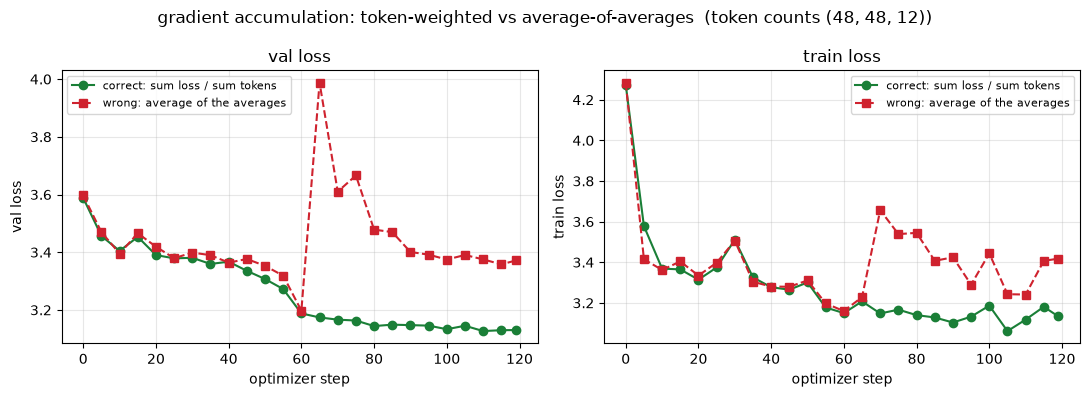

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (ck, wk, title) in zip(
    ax, [("c_val", "w_val", "val loss"), ("c_tr", "w_tr", "train loss")]
):
    a.plot(
        acc_hist["step"],
        acc_hist[ck],
        "o-",
        color="#1a7f37",
        label="correct: sum loss / sum tokens",
    )
    a.plot(
        acc_hist["step"],
        acc_hist[wk],
        "s--",
        color="#cf222e",
        label="wrong: average of the averages",
    )
    a.set_xlabel("optimizer step")
    a.set_ylabel(title)
    a.set_title(title)
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
fig.suptitle(
    f"gradient accumulation: token-weighted vs average-of-averages  (token counts {real_lens})"
)
fig.tight_layout()
fig.savefig("assets/accum_gap.png", dpi=110, bbox_inches="tight")
plt.show()


The two curves start together and pull apart. The "wrong" rule is not random
noise — it systematically over-weights the short micro-batch's gradient, so it
optimises a slightly different objective than the one you think you wrote down.
The fix is one line: **normalise the loss by token, not by micro-batch.**


## 4. Log the grad norm at every step, find where it moved first

The global grad norm is `sqrt(Σ gᵢ²)` over **every** gradient in the model. We
log it, the raw loss, and an EMA-smoothed loss, every step. At one step we feed a
single poisoned batch (targets replaced with noise). That batch has a large
gradient → the norm spikes **immediately**. The optimizer then takes one bad
step, and the smoothed loss only rises on the *next* normal batch.


In [93]:
def global_grad_norm(model):
    sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            sq += float(p.grad.detach().pow(2).sum().item())
    return sq**0.5


In [94]:
n_steps = 50 if SMOKE else 140
inject_step = 30 if SMOKE else 70
seq_len = min(128, cfg.block_size)
ema_beta = 0.25

gnet = copy.deepcopy(net).to(DEVICE).train()
opt = torch.optim.AdamW(gnet.parameters(), lr=3e-3)
gen = torch.Generator().manual_seed(7)


The loop. The grad norm is measured **after `backward()`, before `opt.step()`**.


In [95]:
tr = {"step": [], "loss": [], "loss_ema": [], "gnorm": []}
ema = None
for step in range(n_steps):
    x, y = data.get_batch(ds, "train", 16, seq_len, DEVICE, generator=gen)
    if step == inject_step:
        y = torch.randint(0, ds.vocab_size, y.shape, generator=gen).to(
            DEVICE
        )  # one poisoned batch

    opt.zero_grad(set_to_none=True)
    _, loss = gnet(x, targets=y)
    loss.backward()
    gnorm = global_grad_norm(gnet)
    opt.step()

    lv = float(loss.item())
    ema = lv if ema is None else (1 - ema_beta) * ema + ema_beta * lv
    tr["step"].append(step)
    tr["loss"].append(lv)
    tr["loss_ema"].append(ema)
    tr["gnorm"].append(gnorm)
print(f"logged {len(tr['step'])} steps; poisoned batch at step {inject_step}")


logged 140 steps; poisoned batch at step 70


Where did the norm spike, and where did the smoothed loss actually rise?


In [96]:
gn = np.array(tr["gnorm"])
ls = np.array(tr["loss_ema"])
lo, hi = max(inject_step - 3, 0), min(inject_step + 3, len(gn))
grad_spike = lo + int(np.argmax(gn[lo:hi]))
ref = ls[inject_step - 1]  # smoothed loss just before the poison
loss_rise = next(
    (
        i
        for i in range(inject_step + 1, min(inject_step + 12, len(ls)))
        if ls[i] > ref * 1.05
    ),
    None,
)

print(f"injection step                 : {inject_step}")
print(
    f"grad norm  step {inject_step - 1} -> {inject_step}       : {gn[inject_step - 1]:.3f} -> {gn[inject_step]:.3f}"
)
print(f"grad-norm spike at step        : {grad_spike}")
print(f"smoothed loss rose >5% at step : {loss_rise}")
lead = None if loss_rise is None else loss_rise - grad_spike
print(f"grad norm led the loss by      : {lead} step(s)")
RESULTS["gradnorm_lead_steps"] = lead


injection step                 : 70
grad norm  step 69 -> 70       : 0.809 -> 3.834
grad-norm spike at step        : 70
smoothed loss rose >5% at step : 71
grad norm led the loss by      : 1 step(s)


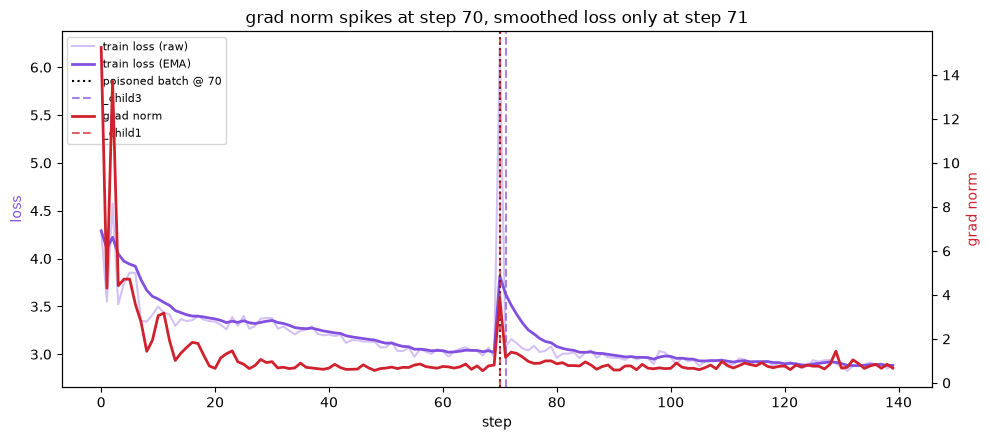

In [97]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(tr["step"], tr["loss"], color="#8250df", alpha=0.35, label="train loss (raw)")
ax1.plot(tr["step"], tr["loss_ema"], color="#8250df", lw=2, label="train loss (EMA)")
ax1.set_xlabel("step")
ax1.set_ylabel("loss", color="#8250df")
ax2 = ax1.twinx()
ax2.plot(tr["step"], tr["gnorm"], color="#cf222e", lw=2, label="grad norm")
ax2.set_ylabel("grad norm", color="#cf222e")
ax1.axvline(inject_step, color="k", ls=":", label=f"poisoned batch @ {inject_step}")
ax2.axvline(grad_spike, color="#cf222e", ls="--", alpha=0.7)
if loss_rise is not None:
    ax1.axvline(loss_rise, color="#8250df", ls="--", alpha=0.7)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=8)
ax1.set_title(
    f"grad norm spikes at step {grad_spike}, smoothed loss only at step {loss_rise}"
)
fig.tight_layout()
fig.savefig("assets/gradnorm_lead.png", dpi=110, bbox_inches="tight")
plt.show()


**On the method.** At this model size and over 140 steps nothing naturally
diverges — in the 70 un-poisoned steps the grad norm and the EMA loss just track
each other down. So we *induce* the event with one poisoned batch to show the
mechanism in miniature: the norm reacts on the step the bad gradient arrives, the
optimizer takes one bad step, and the loss only degrades on the *next* normal
batch. The lead here is a single step; on a real run sliding toward divergence
the grad norm bends up thousands of steps before the loss curve does, which is
why it is the most useful trace on a training dashboard. Clipping
(`clip_grad_norm_`) uses the same number — cap the norm, keep the direction,
scale the length down — and the notes say to have it on from step one.


## 5. Compute your own MFU

$$\text{MFU} = \frac{(6N + \text{attn}) \times \text{tokens per second}}{\text{peak FLOP/s of the accelerator}}$$

`6N` is the standard "6 FLOPs per parameter per token" estimate (2 for the
forward matmul, 4 for the backward). The attention term
`6 · n_layer · 2 · T · Dh · H` covers the `q@kᵀ` and `attn@v` matmuls that don't
live in the parameters.


In [ ]:
mfu_batch, mfu_seq = (
    16,
    min(256, cfg.block_size),
)  # used for flops/token AND the timed loop

N = net.num_params(non_embedding=True)
attn_flops = 6 * cfg.n_layer * (2 * mfu_seq * (cfg.n_embd // cfg.n_head) * cfg.n_head)
flops_per_token = 6 * N + attn_flops
print(f"N (non-embedding params) : {N:,}")
print(f"6N                       : {6 * N:,}")
print(f"attention term           : {attn_flops:,}")
print(f"flops/token              : {flops_per_token:,}")
RESULTS["mfu_flops_per_token"] = flops_per_token


N (non-embedding params) : 10,672,512
6N                       : 64,035,072
attention term           : 7,077,888
flops/token              : 71,112,960


Now time a real forward + backward + optimizer loop.


In [99]:
mnet = copy.deepcopy(net).to(DEVICE).train()
opt = torch.optim.AdamW(mnet.parameters(), lr=3e-3)
bs, sl = mfu_batch, mfu_seq  # same batch/seq the flops/token estimate used
warmup, measure = 5, (10 if SMOKE else 30)
use_amp = DEVICE.type == "cuda"
gen = torch.Generator().manual_seed(11)


def one_step():
    x, y = data.get_batch(ds, "train", bs, sl, DEVICE, generator=gen)
    opt.zero_grad(set_to_none=True)
    if use_amp:
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            _, loss = mnet(x, targets=y)
    else:
        _, loss = mnet(x, targets=y)
    loss.backward()
    opt.step()


In [100]:
for _ in range(warmup):
    one_step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()
for _ in range(measure):
    one_step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - t0

tokens = measure * bs * sl
tok_per_sec = tokens / elapsed
achieved = flops_per_token * tok_per_sec  # FLOP/s
print(f"dtype          : {'bf16 autocast' if use_amp else 'fp32'}")
print(f"mean step time : {1000 * elapsed / measure:.2f} ms")
print(f"tokens/sec     : {tok_per_sec:,.0f}")
print(f"achieved       : {achieved / 1e12:,.3f} TFLOP/s")
RESULTS["mfu_tokens_per_sec"] = tok_per_sec


dtype          : bf16 autocast
mean step time : 39.60 ms
tokens/sec     : 103,425
achieved       : 7.355 TFLOP/s


The denominator: the accelerator's dense peak. `S10_PEAK_TFLOPS` overrides the
small built-in lookup; on CPU it falls back to a meaningless placeholder.


In [101]:
PEAK_TFLOPS = {
    "h100": 989,
    "h200": 989,
    "a100": 312,
    "a6000": 155,
    "6000 ada": 364,
    "4090": 165,
    "l40": 181,
    "l4": 121,
    "v100": 125,
    "t4": 65,
}
dev_name = utils.device_name(DEVICE).lower()
if os.environ.get("S10_PEAK_TFLOPS"):
    peak, src = float(os.environ["S10_PEAK_TFLOPS"]), "S10_PEAK_TFLOPS env"
else:
    hit = next((k for k in PEAK_TFLOPS if k in dev_name), None)
    peak, src = (
        (PEAK_TFLOPS[hit], f"matched '{hit}'")
        if hit
        else (0.5, "CPU placeholder -- set S10_PEAK_TFLOPS")
    )
print(f"peak ({src}) : {peak:.1f} TFLOP/s")


peak (matched 'a6000') : 155.0 TFLOP/s


In [102]:
mfu = (achieved / 1e12) / peak
print(f"MFU            : {mfu * 100:.2f} %")
print(f"distance to 40%: {max(0.0, 0.40 - mfu) * 100:.2f} points")
RESULTS["mfu_pct"] = mfu * 100


MFU            : 4.75 %
distance to 40%: 35.25 points


### what is costing us the distance to 40%

This number is **low**, and it should be. Roughly in order of impact for this
run (10.7M params, batch 16 × seq 256, bf16 autocast, RTX A6000):

1. **Tiny model.** At 10.7M params `6N` is small, so each token is cheap in FLOPs
   but still pays full kernel-launch and Python-loop overhead. MFU climbs with
   model size — this proxy sits well below where an A6000 saturates.
2. **Small batch / short sequences.** The matmuls are memory-bandwidth bound, not
   compute bound. Bigger `B` and `T` amortise the weight reads.
3. **No `torch.compile` / no fused kernels.** Eager mode launches hundreds of
   small kernels per step; only attention (SDPA) is fused.
4. **bf16 autocast, not a fully low-precision path.** LayerNorm, the loss
   reduction and the optimizer still run in fp32; the peak column assumes pure
   bf16 tensor-core throughput.
5. **Optimizer + sync points.** AdamW is elementwise and bandwidth-bound; every
   `loss.item()` forces a device sync that stalls the pipeline.
6. **The attention term grows as `T²`** and is not in `6N` — it is already ~10%
   of flops/token at `T = 256`, and at long context it eats real time the `6N`
   estimate ignores, depressing measured MFU further.

The fixes are the next sessions: bigger models, a bigger global batch via
gradient accumulation, `torch.compile`, activation checkpointing, and a
lower-precision format chosen on purpose.


## 6. The number 0.1 in fp32, bf16 and fp8 E4M3

`0.1` is not exactly representable in binary — it is `0.0001100110011…`
repeating. Each format rounds that infinite tail at a different place.

**By hand.** `0.1 = 1.6 × 2⁻⁴`, so the unbiased exponent is `−4` in every format
below, and the significand is `1.6` (fraction `0.6`). To get the mantissa bits,
scale the fraction by `2^(mantissa width)` and round to nearest:

- fp32 (23 mantissa bits): `0.6 × 2²³ = 5033164.8 → 5033165` → `10011001100110011001101`
- bf16 (7 bits): `0.6 × 2⁷ = 76.8 → 77` → `1001101`
- fp8 E4M3 (3 bits): `0.6 × 2³ = 4.8 → 5` → `101`

Exponent field = unbiased + bias: fp32 `−4 + 127 = 123 = 01111011`, bf16 same,
fp8 E4M3 `−4 + 7 = 3 = 0011`.

**fp32 and bf16 from the actual bits** — fp32 via `struct`, bf16 as fp32's top 16
bits with round-to-nearest-even on the discarded 16.


In [103]:
def fp32_bits(x):
    (u,) = struct.unpack(">I", struct.pack(">f", x))
    b = f"{u:032b}"
    return b[0], b[1:9], b[9:], struct.unpack(">f", struct.pack(">f", x))[0]


def bf16_bits(x):
    u = np.float32(x).view(np.uint32)
    bias = np.uint32(0x7FFF) + ((u >> np.uint32(16)) & np.uint32(1))
    u16 = int((u + bias) >> np.uint32(16)) & 0xFFFF
    b = f"{u16:016b}"
    stored = np.uint32(u16 << 16).view(np.float32)
    return b[0], b[1:9], b[9:], float(stored)


s, e, m, v = fp32_bits(0.1)
print(f"fp32  {s} {e} {m}  = {v:.12f}")
s, e, m, v = bf16_bits(0.1)
print(f"bf16  {s} {e} {m}          = {v:.12f}")


fp32  0 01111011 10011001100110011001101  = 0.100000001490
bf16  0 01111011 1001101          = 0.100097656250


**fp8 E4M3 by hand** — 1 sign, 4 exponent (bias 7), 3 mantissa. Not IEEE: there
is **no infinity**, and the single pattern `S.1111.111` is **reserved for NaN** —
which is why the largest *finite* magnitude is `S.1111.110` = 448, not 480.
Round-to-nearest-ties-to-even on 3 mantissa bits, carry into the exponent, and
**saturate to 448** both on overflow and when rounding would land in the NaN slot
(e.g. `470.0` → `0 1111 110` = 448.0).


In [104]:
def fp8_e4m3(x):
    # NOT IEEE: no infinity, and the single pattern S.1111.111 is reserved for
    # NaN -- so the largest finite magnitude is S.1111.110 = 448. Round-to-
    # nearest-ties-to-even; saturate to 448 on overflow and on the NaN slot.
    s = "1" if x < 0 else "0"
    ax, bias = abs(float(x)), 7
    if ax == 0.0:
        return s, "0000", "000", 0.0
    e = math.floor(math.log2(ax))
    exp_field = e + bias
    if exp_field <= 0:  # subnormal
        step = 2.0 ** (1 - bias - 3)
        q = min(round(ax / step), 7)
        return s, "0000", f"{q:03b}", q * step
    frac = ax / (2.0**e) - 1.0  # significand fraction, in [0, 1)
    scaled = frac * 8.0
    m = int(math.floor(scaled))
    rem = scaled - m
    if rem > 0.5 or (rem == 0.5 and m % 2 == 1):
        m += 1
    if m == 8:  # mantissa carried into the exponent
        m, exp_field = 0, exp_field + 1
    if exp_field > 15 or (exp_field == 15 and m == 7):  # overflow / NaN slot
        exp_field, m = 15, 6
    stored = (1.0 + m / 8.0) * 2.0 ** (exp_field - bias)
    return s, f"{exp_field:04b}", f"{m:03b}", stored


s, e, m, v = fp8_e4m3(0.1)
print(f"fp8 E4M3  {s} {e} {m}  = {v:.12f}")


fp8 E4M3  0 0011 101  = 0.101562500000


All three side by side:


In [105]:
target = 0.1
rows = [
    ("fp32", *fp32_bits(target)[:3], fp32_bits(target)[3]),
    ("bf16", *bf16_bits(target)[:3], bf16_bits(target)[3]),
    ("fp8 E4M3", *fp8_e4m3(target)[:3], fp8_e4m3(target)[3]),
]

print(f"  {'format':<10} {'sign  exp       mantissa':<32} {'value':<16} rel error")
print(f"  {'-' * 10} {'-' * 32} {'-' * 16} {'-' * 10}")
for fmt, s, e, m, val in rows:
    print(
        f"  {fmt:<10} {s + ' ' + e + ' ' + m:<32} {val:<16.12f} {abs(val - target) / target:.2e}"
    )
RESULTS["float_0p1"] = {
    fmt: {"bits": f"{s} {e} {m}", "value": val, "rel_err": abs(val - target) / target}
    for fmt, s, e, m, val in rows
}


  format     sign  exp       mantissa         value            rel error
  ---------- -------------------------------- ---------------- ----------
  fp32       0 01111011 10011001100110011001101 0.100000001490   1.49e-08
  bf16       0 01111011 1001101               0.100097656250   9.77e-04
  fp8 E4M3   0 0011 101                       0.101562500000   1.56e-02


In [106]:
# a couple more values, to show the sign bit, the 448 clamp, and a subnormal
for t in (-0.1, 448.0, 1000.0, 0.001):
    s, e, m, v = fp8_e4m3(t)
    print(f"fp8 E4M3   {t:>8} -> {s} {e} {m}   = {v}")


fp8 E4M3       -0.1 -> 1 0011 101   = 0.1015625
fp8 E4M3      448.0 -> 0 1111 110   = 448.0
fp8 E4M3     1000.0 -> 0 1111 110   = 448.0
fp8 E4M3      0.001 -> 0 0000 001   = 0.001953125


### Which would I train in, and why

**bf16 — with an fp32 master copy of the weights** (the standard
mixed-precision recipe).

- **fp32** is the safe reference but doubles memory and bandwidth for detail
  training does not need. Used only for the master weights, the optimizer
  moments, and reductions (loss, norms).
- **fp16** has only 5 exponent bits; late-run gradients near `10⁻⁸` underflow to
  exactly zero and that weight silently stops learning. It needs loss scaling —
  one more thing to tune and get wrong.
- **bf16** keeps all 8 exponent bits, so its range equals fp32's and nothing in
  training underflows. It pays with precision — 2–3 decimal digits — which is
  fine for the forward/backward math because the fp32 master weights and fp32
  optimizer accumulate the small updates that bf16 alone would round away.
- **fp8 E4M3** (1.6% error on `0.1`) only works blockwise, with per-block scales,
  attention kept in higher precision, and a handful of other tricks. A 2026
  production recipe, not the thing to *start* a from-scratch run in.

So: **bf16 for the model math, fp32 where it's cheap and matters.**


## 7. Sanity: the loop learns

Everything above is instrumentation. A short real run to confirm the five lines
actually drive the loss down, with grad-norm clipping on from step one as the
notes prescribe.


In [107]:
train_net = model_mod.GPT(cfg).to(DEVICE).train()
opt = torch.optim.AdamW(train_net.parameters(), lr=3e-3)
n_steps = 60 if SMOKE else 400
seq_len = min(128, cfg.block_size)
sanity_hist = {"step": [], "loss": [], "gnorm": []}
gen = torch.Generator().manual_seed(0)


In [108]:
t0 = time.perf_counter()
for step in range(n_steps):
    x, y = data.get_batch(ds, "train", 32, seq_len, DEVICE, generator=gen)
    opt.zero_grad(set_to_none=True)
    _, loss = train_net(x, targets=y)
    loss.backward()
    gnorm = torch.nn.utils.clip_grad_norm_(
        train_net.parameters(), 1.0
    )  # clip from step one
    opt.step()
    if step % max(1, n_steps // 20) == 0 or step == n_steps - 1:
        sanity_hist["step"].append(step)
        sanity_hist["loss"].append(loss.item())
        sanity_hist["gnorm"].append(float(gnorm))
dt = time.perf_counter() - t0

print(
    f"start loss : {sanity_hist['loss'][0]:.3f}   (ln V = {math.log(ds.vocab_size):.3f})"
)
print(f"end   loss : {sanity_hist['loss'][-1]:.3f}")
print(f"wall time  : {dt:.1f}s for {n_steps} steps")
RESULTS["train_start_loss"] = sanity_hist["loss"][0]
RESULTS["train_end_loss"] = sanity_hist["loss"][-1]


start loss : 4.214   (ln V = 4.174)
end   loss : 2.691
wall time  : 14.7s for 400 steps


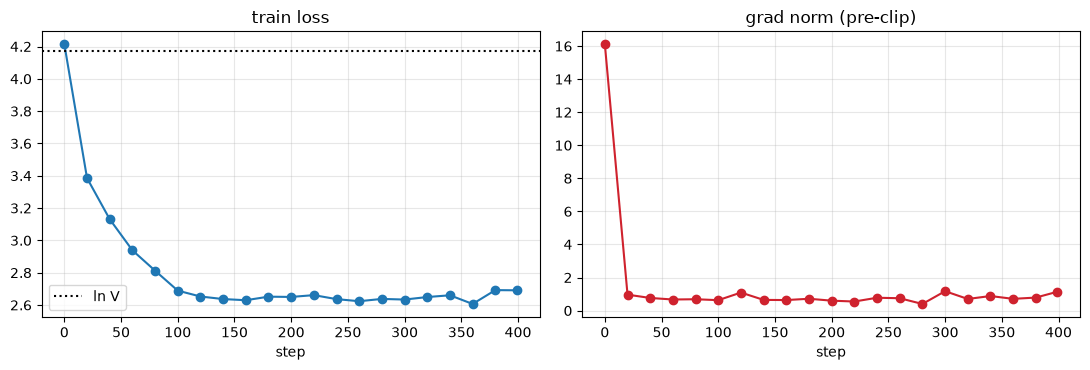

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(sanity_hist["step"], sanity_hist["loss"], "o-")
ax[0].set_title("train loss")
ax[0].set_xlabel("step")
ax[0].grid(alpha=0.3)
ax[0].axhline(math.log(ds.vocab_size), ls=":", color="k", label="ln V")
ax[0].legend()
ax[1].plot(sanity_hist["step"], sanity_hist["gnorm"], "o-", color="#cf222e")
ax[1].set_title("grad norm (pre-clip)")
ax[1].set_xlabel("step")
ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("assets/train_curve.png", dpi=110, bbox_inches="tight")
plt.show()


In [110]:
train_net.eval()
ctx = torch.tensor([[ds.stoi.get("\n", 0)]], dtype=torch.long, device=DEVICE)
out = train_net.generate(ctx, max_new_tokens=200, temperature=0.8)
print(ds.decode(out[0].tolist()))





Cotheferey cowi,fake le, bth

Hirere obe ale.
S:BOSED:
Bdelatauss:
Warthare wecrl t.
War dthasomee ar ce myathandanoum orour
Yowhe
MUUf itir ble mil ndile,


W ireeesenecin latisthid ov te, athe me 


## 8. The numbers, in one place


In [111]:
print(json.dumps(RESULTS, indent=2, default=str))
with open("assets/results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("\nsaved assets/results.json")


{
  "config": {
    "vocab_size": 65,
    "block_size": 256,
    "n_layer": 6,
    "n_head": 6,
    "n_embd": 384,
    "dropout": 0.0,
    "bias": true
  },
  "params_total": 10770816,
  "params_non_embedding": 10672512,
  "grad_shape_mismatches": 0,
  "gradcheck_analytic": 0.008106809184605374,
  "gradcheck_numeric": 0.008106809166186224,
  "gradcheck_matching_decimals": 10,
  "accum_static_correct": 2.6,
  "accum_static_wrong": 3.0,
  "accum_static_rel_err_pct": 15.384615384615381,
  "accum_final_val_correct": 3.1302857398986816,
  "accum_final_val_wrong": 3.3714194297790527,
  "gradnorm_lead_steps": 1,
  "mfu_flops_per_token": 71112960,
  "mfu_tokens_per_sec": 103425.18560118788,
  "mfu_pct": 4.745078120419258,
  "float_0p1": {
    "fp32": {
      "bits": "0 01111011 10011001100110011001101",
      "value": 0.10000000149011612,
      "rel_err": 1.4901161138336505e-08
    },
    "bf16": {
      "bits": "0 01111011 1001101",
      "value": 0.10009765625,
      "rel_err": 0.00097656249